# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_08. Seven trials recorded:

- trial_01 = target, h_f 5.349, h_s 7.652 -> 0.0837.
- trial_02 = sim, h_f 5.308, h_s 3.060 -> 0.1249.
- trial_03 = power, h_f 8.658, h_s 4.220 -> 0.1541.
- trial_04 = target, h_f 9.821, h_s 2.920 -> 0.0926.
- trial_05 = target, h_f 3.580, h_s 5.784 -> 0.0818 (current best).
- trial_06 = target, h_f 3.678, h_s 5.319 -> 0.0890.
- trial_07 = target, h_f 1.130, h_s 8.612 -> 0.1165.

Ranking: target plateau h_f 3.5-5.5 at 0.080-0.089 (best trail_05 0.0818, exp6 0.0803), target edges
worse (0.1165 @ 1.13, 0.0926 @ 9.82), sim 0.1249, power 0.1541. The target-rule optimum is bracketed to
a noise-flat plateau centred near h_f ~4, and the EI proposals now concentrate there.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 2.2523 | {"bandwidth_rule": "target", "h_f_scale": 4.183269923340953, "h_s_scale": 5.561351457155482}
 2 | 2.6421 | {"bandwidth_rule": "target", "h_f_scale": 4.394663733604091, "h_s_scale": 6.268619995789886}
 3 | 1.5446 | {"bandwidth_rule": "target", "h_f_scale": 3.032047125178564, "h_s_scale": 9.95210437170523}
 4 | 0.8153 | {"bandwidth_rule": "target", "h_f_scale": 7.499931369419527, "h_s_scale": 5.494122389905412}
 5 | 1.0613 | {"bandwidth_rule": "power", "h_f_scale": 5.085258412866358, "h_s_scale": 1.1846025755689582}
 6 | 3.0106 | {"bandwidth_rule": "target", "h_f_scale": 3.7793360132235936, "h_s_scale": 7.278991718815376}
 7 | 0.3302 | {"bandwidth_rule": "sim", "h_f_scale": 2.4738584497931697, "h_s_scale": 2.0571927688096174}
 8 | 2.4457 | {"bandwidth_rule": "target", "h_f_scale": 2.7927156082927085, "h_s_scale": 6.53542144911894}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 8.921115677369045, "h_s_scale": 11.8765

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Every high-EI proposal is now a `target` configuration inside the plateau (h_f 2.8-4.4), which is exactly
what the evidence predicts. Since the plateau is noise-flat, the decision is simply which plateau point has
the best EI: #6 (target 3.779, h_s 7.279, EI 3.011) is clearly highest, ahead of #2 (4.395/6.269, 2.642) and
#8 (2.793/6.535, 2.446). #6 also sits centrally in the best band (h_f ~3.8, between the 3.58 best and exp6's
4.0), so it is the most sensible pick. The non-target proposals (#5, #7, #10) are on rules already shown to
be clearly worse and carry much lower EI.

I choose candidate 6 (target, h_f_scale 3.779, h_s_scale 7.279).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 3.7793360132235936, 'h_s_scale': 7.278991718815376}
Running  1nW Trans05 ... 

μ 9.39 -> 5.97 | γ 8.5 -> 6.14 | NLL 0.17


Running  1nW Trans20 ... 

μ 17.32 -> 28.04 | γ 8.5 -> 5.39 | NLL 0.47


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.70 | γ 14.1 -> 13.96 | NLL 0.61


Running 3nW Trans100 ... 

μ 175.71 -> 99.04 | γ 14.1 -> 13.81 | NLL 0.60



Total: 7.6 min


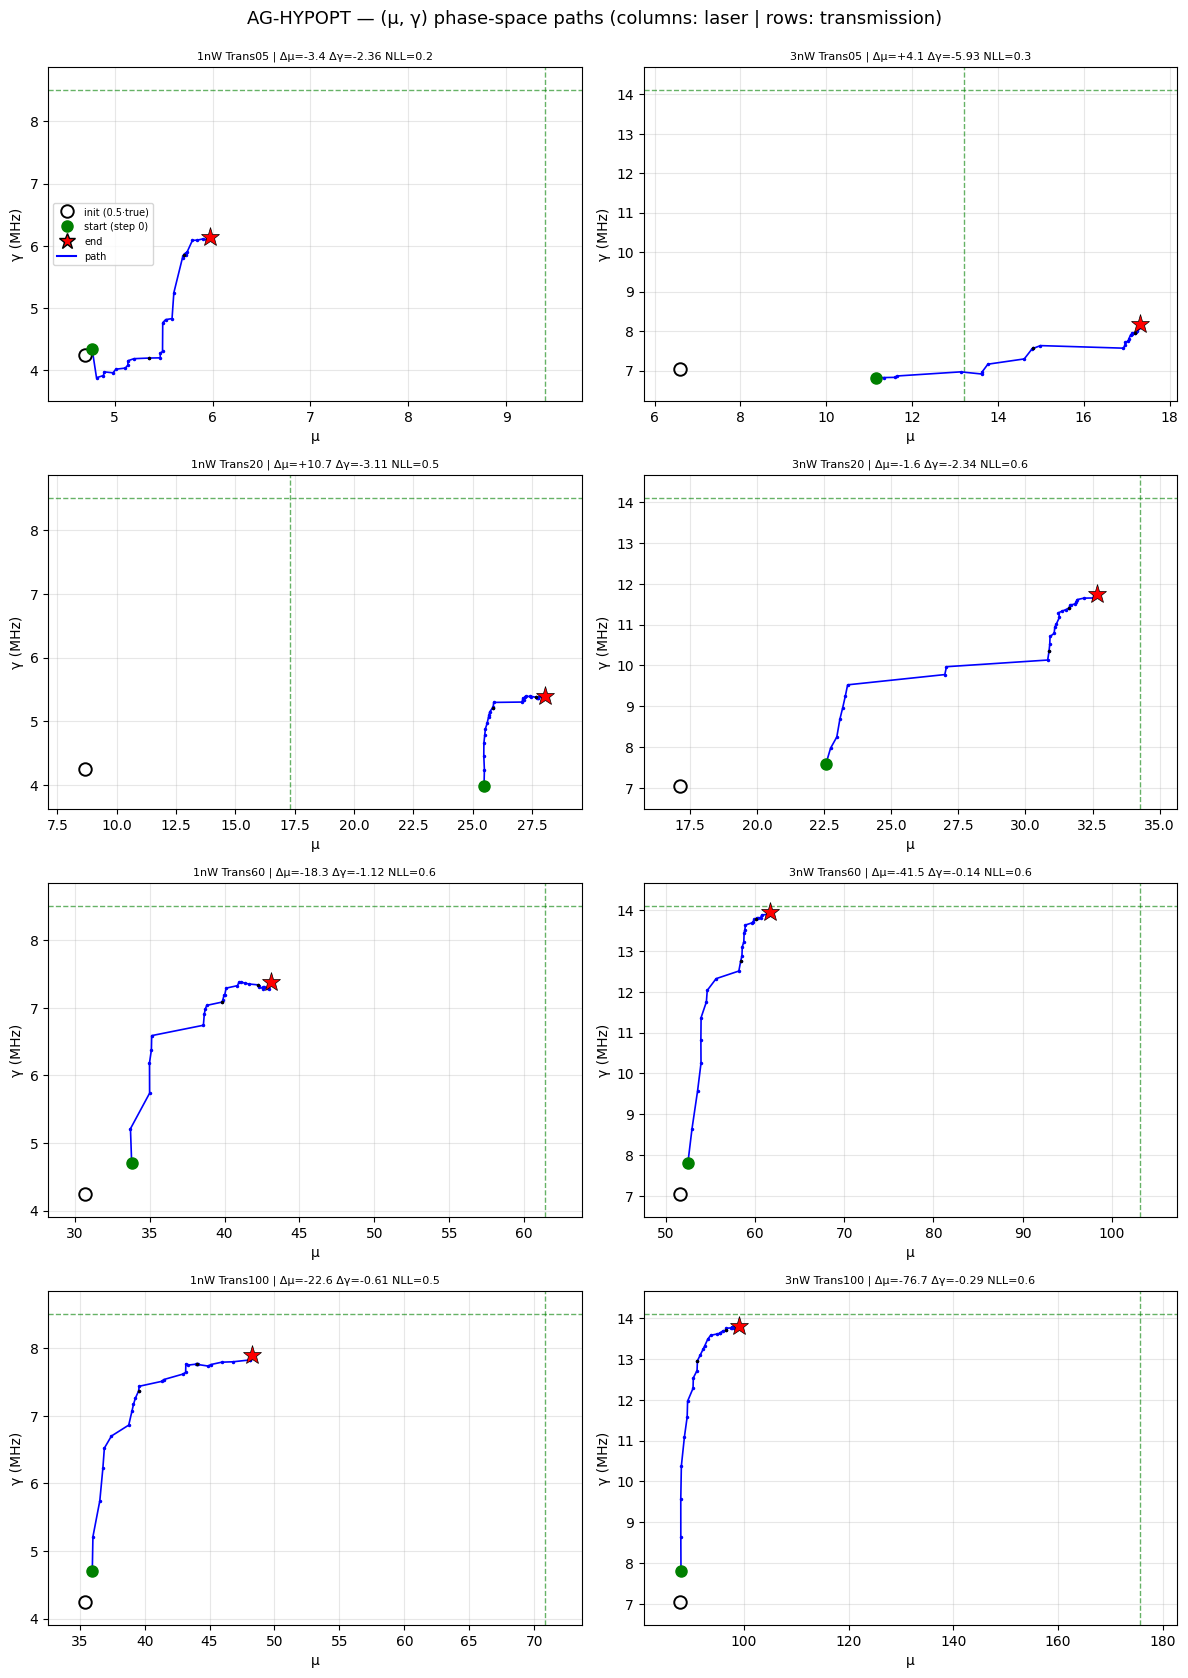

trial finished in 7.7 min
objective = 0.0882 ± 0.0251
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.97   -36.4 |     8.50    6.14   -27.8
1nW Trans20       17.32   28.04   +61.9 |     8.50    5.39   -36.5
1nW Trans60       61.37   43.10   -29.8 |     8.50    7.38   -13.2
1nW Trans100       70.82   48.24   -31.9 |     8.50    7.89    -7.1
3nW Trans05       13.20   17.31   +31.1 |    14.10    8.17   -42.0
3nW Trans20       34.28   32.68    -4.7 |    14.10   11.76   -16.6
3nW Trans60      103.20   61.70   -40.2 |    14.10   13.96    -1.0
3nW Trans100      175.71   99.04   -43.6 |    14.10   13.81    -2.1

weighted objective (T-graded, cap=1.0) = 0.0882 | diverged cells: 0
μ: RMSE 32.767 (rel 38.0%, bias -18.652) | γ: RMSE 2.683 (rel 23.4%, bias -1.987)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

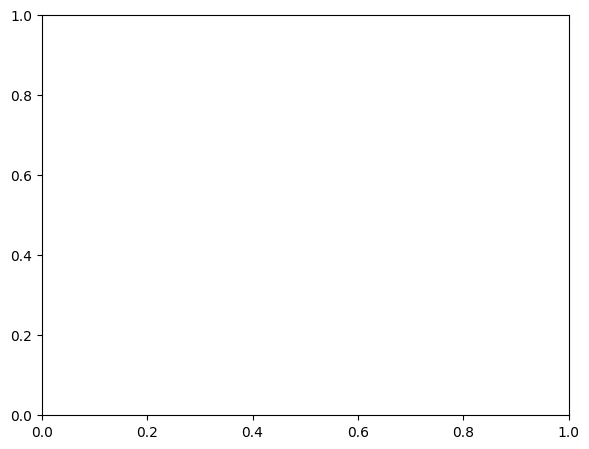

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0882 ± 0.0251, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 3.779, h_s_scale = 7.279 - the highest-EI proposal, a central plateau point.

Standard campaign signature: mu mixed-sign (1nW Trans20 +61.9 %, 3nW Trans05 +31.1 %, the rest -4 to -44 %),
gamma underestimated everywhere with high-T nearly exact (3nW Trans60 -1.0 %, 3nW Trans100 -2.1 %).

This is another sample inside the target plateau, landing at 0.0882 - between the 0.0837 (trial_01) and
0.0890 (trial_06) samples and indistinguishable from them given SE ~0.025. The plateau samples now read
0.0803 (exp6 @4.0), 0.0818 (3.58), 0.0837 (5.35), 0.0882 (3.78), 0.0890 (3.68): a flat cloud of ~5 points
spanning 0.081-0.089 with no trend in h_f or h_s inside the band. The best recorded value remains exp6's
0.0803; no campaign trial has beaten it, and given the SE this is expected.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 8 (target rule, h_f 3.779, h_s 7.279) scores objective 0.0882 ± 0.0251, another plateau sample consistent with the flat 0.081-0.089 band around the target-rule optimum.
**Key insight:** The target plateau now has five samples in 0.081-0.089 with no internal trend, confirming the objective in h_f ~3-5.5 is noise-flat and that exp6's 0.0803 is the best value the target rule reaches.

Notes for Anuar (optional, not acted on): none new beyond the plateau picture.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 8 (target rule, h_f 3.779, h_s 7.279) scores objective 0.0882 ± 0.0251, another plateau sample consistent with the flat 0.081-0.089 band around the target-rule optimum."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The target plateau now has five samples in 0.081-0.089 with no internal trend, confirming the objective in h_f ~3-5.5 is noise-flat and that exp6's 0.0803 is the best value the target rule reaches."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
